In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [21]:
data = {
    'Date':pd.date_range('2023-01-01', periods=36, freq='ME'),
    "Sales":[
        100,112,121,133,141,152,
        160,171,182,171,161,149,

        118,131,142,151,163,174,
        182,194,203,191,183,171,

        141,152,163,174,185,193,
        202,214,223,212,201,191
    ]
    }
df = pd.DataFrame(data)
df.set_index('Date',inplace=True)
df.head()

,Sales
Date,
2023-01-31,100
2023-02-28,112
2023-03-31,121
2023-04-30,133
2023-05-31,141


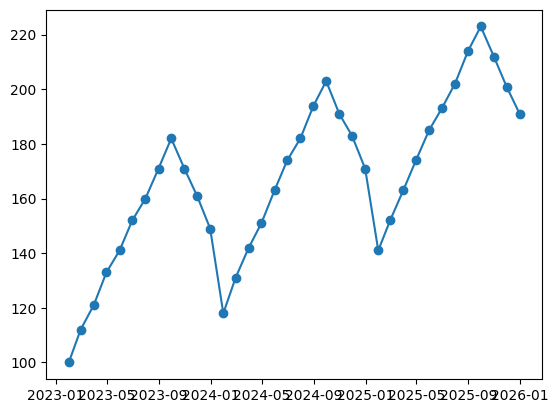

In [22]:
plt.plot(df['Sales'],marker='o')
plt.show()

ADF Test

In [23]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Sales'])

print('adf stats',result[0])
print('p-value',result[1])

adf stats 0.2700430757505503
p-value 0.9759275550942403


In [24]:
df['sales_diff'] = df['Sales'].diff()
df_diff = df['sales_diff'].dropna()

In [25]:
result = adfuller(df_diff)

print('adf stats',result[0])
print('p-value',result[1])

adf stats -23.73674572440207
p-value 0.0


lets find p

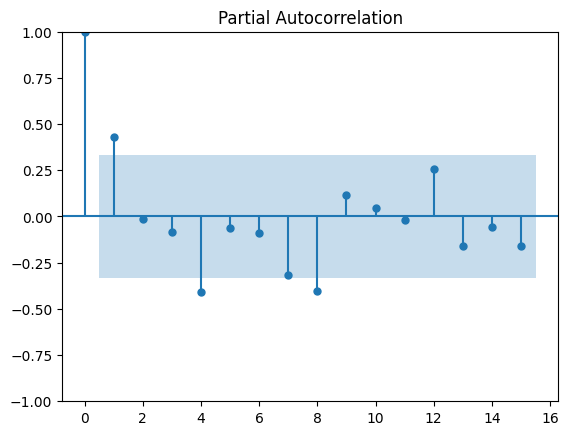

In [26]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df_diff,lags=15)
plt.show()

find q

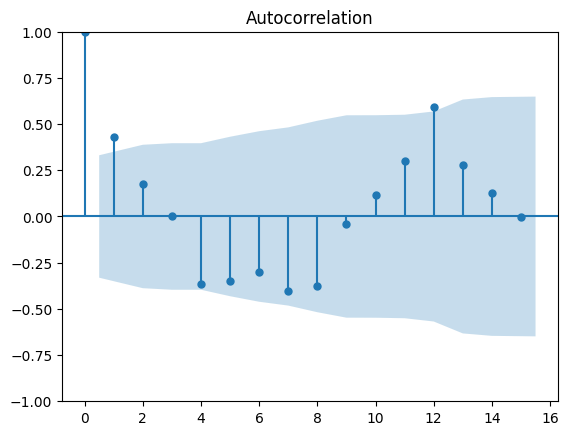

In [27]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df_diff,lags=15)
plt.show()

Find D

In [28]:
df['Seasonal_Diff'] = df['Sales'].diff(12)

seasonal_diff = df['Seasonal_Diff'].dropna()

In [29]:
result = adfuller(seasonal_diff)
print(result[1])

0.003696476814684254


p-value <0.05

Then

D = 1

Find P

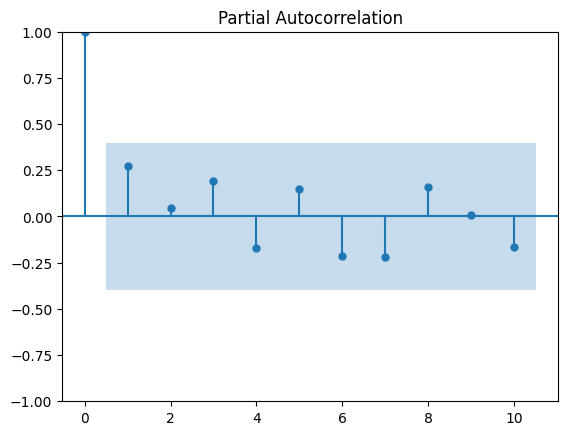

In [31]:
plot_pacf(seasonal_diff,lags=10)
plt.show()

In [32]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    df["Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

model_fit = model.fit()

print(model_fit.summary())

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   36
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -39.690
Date:                            Fri, 17 Jul 2026   AIC                             89.380
Time:                                    03:00:30   BIC                             95.058
Sample:                                01-31-2023   HQIC                            90.808
                                     - 12-31-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1824      0.319     -0.572      0.568      -0.808       0.443
ma.L1         -0.5469      0.304   

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [33]:
forcast = model_fit.forecast(steps=6)

print(forcast)

2026-01-31    159.467944
2026-02-28    171.754033
2026-03-31    183.475266
2026-04-30    192.563473
2026-05-31    205.447687
2026-06-30    214.652260
Freq: ME, Name: predicted_mean, dtype: float64
